# 04 — Model 2: Intervention Effectiveness (for PECH)

Retrospective analysis to understand **which interventions are associated with lower chronic homelessness**.

## Two components
- **Component A — Kaplan-Meier**: survival curves showing how long clients avoid chronic status, split by whether they received each intervention
- **Component B — LightGBM retrospective**: feature importance and SHAP on aggregated 12-month history

> ⚠️ **Association ≠ Causation.** A client with Case Management may have lower chronic risk because the intervention works, OR because caseworkers assign it to lower-risk clients. Always interpret with caution.

In [15]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import joblib
from datetime import date

from src.data_loader import load_valid_cam
from src.feature_engineering import build_training_dataset, get_X_y
from src.config import TRAIN_TEST_DATE, CAT_FEATURES, PHASE_A_FEATURES, HOUSING_TYPE_MAPPING

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 50)

INTERVENTIONS = [
    'Goods and Services', 'Case Management', 'Group Activities',
    'Service Restrictions', 'SPDAT', 'Housing Placement',
    'Follow Ups', 'Housing Retention',
]

## 1. Load data

In [16]:
cam = load_valid_cam('../data/raw/D4G_CAM_Final.xlsx')
training_df = build_training_dataset(cam)   # one row per client, includes became_chronic

print(f"CAM: {cam.shape[0]:,} rows, {cam['Dummy Client ID'].nunique():,} unique clients")
print(f"Training dataset: {training_df.shape[0]:,} clients")

Loaded CAM: 59,624 rows, 10,118 unique clients
After cut-off (2025-02-28): 9,576 valid clients (542 excluded — entered system too recently)
Targets derived: 3,259 chronic (34.0%) / 6,317 non-chronic
Intake records built: 9,576 clients

Training dataset: 9,576 rows x 69 cols
Phase A features available: 19/19
Phase B features available: 23/23
CAM: 58,656 rows, 9,576 unique clients
Training dataset: 9,576 clients


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  targets = cam.groupby('Dummy Client ID').apply(client_target).reset_index()


---
# Component A — Kaplan-Meier Survival Analysis

**`time_in_system`**: days from first record to:
- Date of becoming chronic (for chronic clients, `event = 1`)
- Last record in dataset (for non-chronic clients, `event = 0` — censored)

For each intervention, we compare survival curves: clients who received it vs. those who did not.

In [17]:
# Build Kaplan-Meier dataset — one row per client, ALL snapshots
first_date = cam.groupby('Dummy Client ID')['Date'].min().rename('first_date')
last_date  = cam.groupby('Dummy Client ID')['Date'].max().rename('last_date')

km_df = training_df[['Dummy Client ID', 'became_chronic', 'date_became_chronic']].copy()
km_df = km_df.merge(first_date, on='Dummy Client ID')
km_df = km_df.merge(last_date,  on='Dummy Client ID')

# time_in_system: days to chronic event OR days to last observation (censored)
km_df['end_date'] = km_df['date_became_chronic'].where(
    km_df['became_chronic'] == 1, km_df['last_date']
)
km_df['time_in_system'] = (km_df['end_date'] - km_df['first_date']).dt.days.clip(lower=1)
km_df['event'] = km_df['became_chronic']

# Add 8 binary flags: has_* = 1 if client received intervention in ANY snapshot
for intv in INTERVENTIONS:
    col_name = 'has_' + intv.lower().replace(' ', '_').replace('/', '_')
    clients_with = cam[cam['Recent Interaction Module'] == intv]['Dummy Client ID'].unique()
    km_df[col_name] = km_df['Dummy Client ID'].isin(clients_with).astype(int)

print(f"KM dataset: {km_df.shape[0]:,} clients")
print(f"Chronic: {km_df['event'].sum():,} | Censored: {(km_df['event']==0).sum():,}")
print(f"\nAvg time_in_system: {km_df['time_in_system'].mean():.0f} days")
km_df.head(3)

KM dataset: 9,576 clients
Chronic: 3,259 | Censored: 6,317

Avg time_in_system: 101 days


,Dummy Client ID,became_chronic,date_became_chronic,first_date,last_date,end_date,time_in_system,event,has_goods_and_services,has_case_management,has_group_activities,has_service_restrictions,has_spdat,has_housing_placement,has_follow_ups,has_housing_retention
0,A102A28,1,2025-07-31,2025-07-31,2025-08-31,2025-07-31,1,1,0,0,0,0,0,0,0,0
1,A109E15,0,NaT,2023-01-31,2023-01-31,2023-01-31,1,0,0,0,0,0,0,0,0,0
2,A110B58,0,NaT,2024-07-31,2024-09-30,2024-09-30,61,0,1,0,0,0,0,0,0,0


## Component A-2: Kaplan-Meier curves per intervention

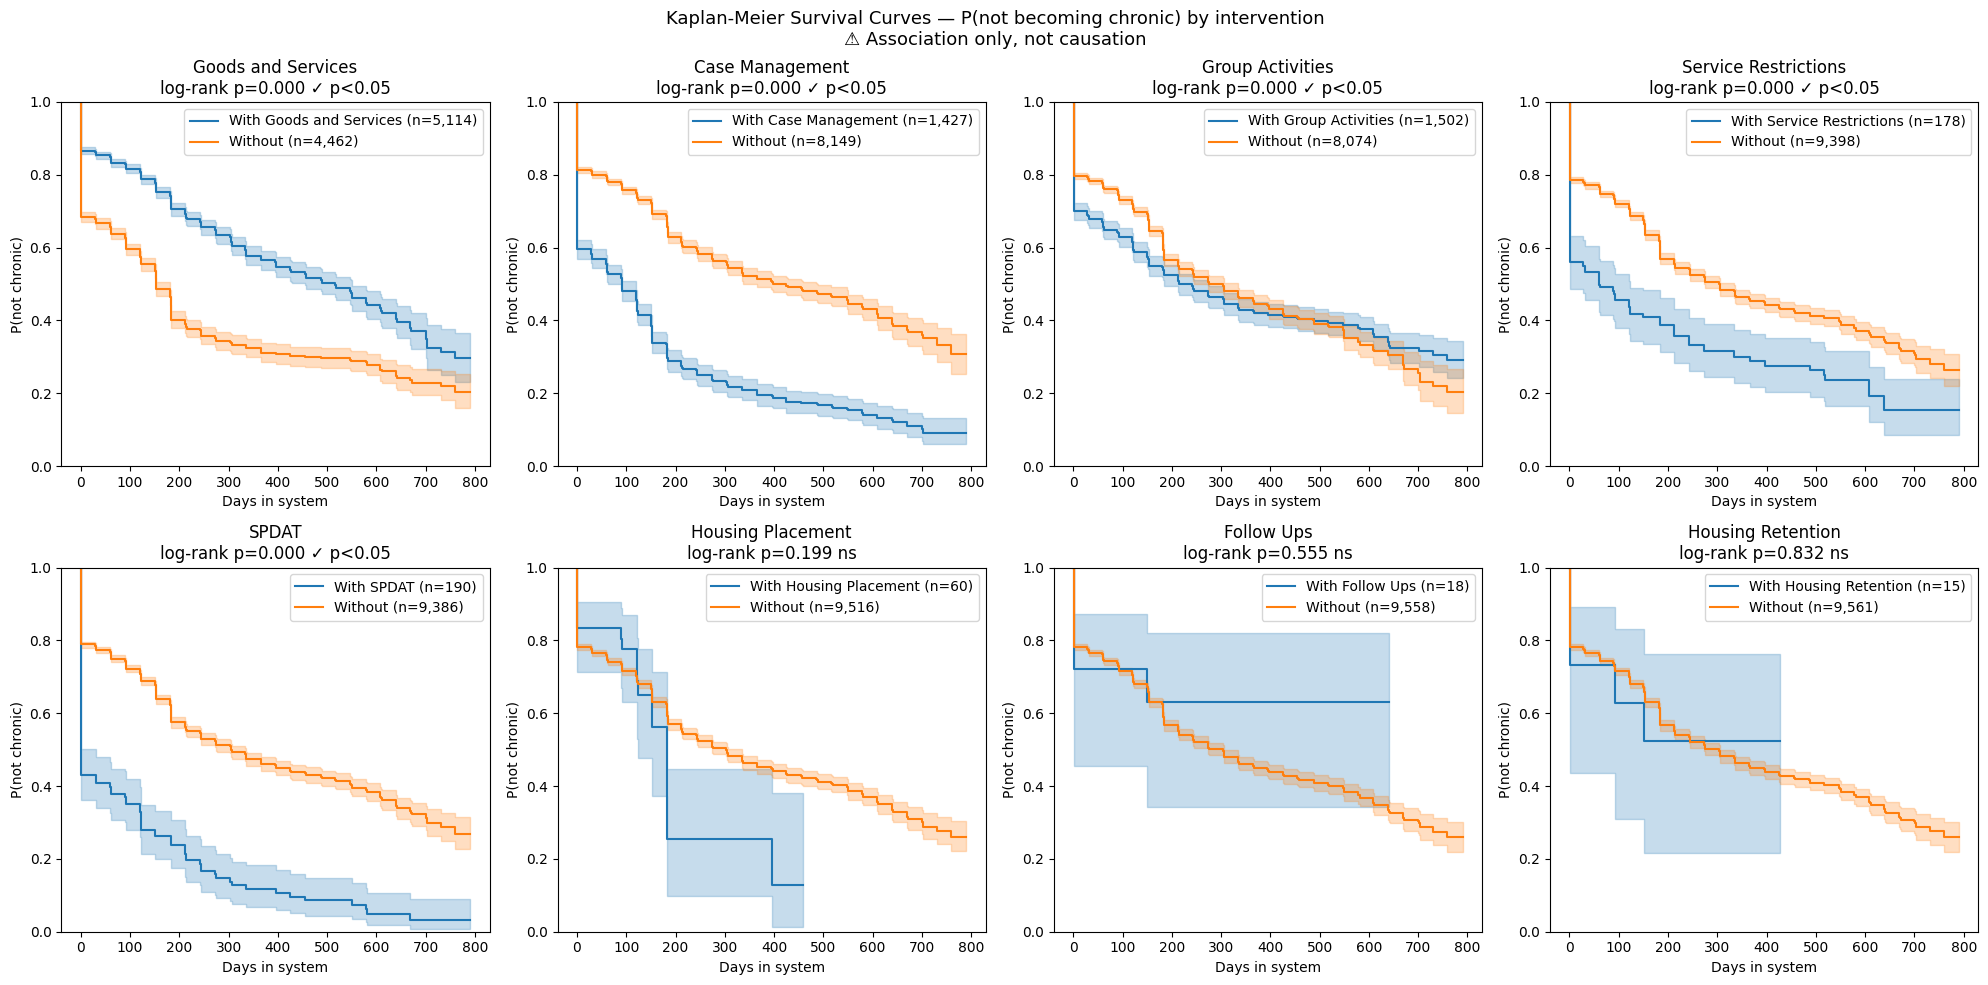


Log-rank test results:
        intervention  n_with  n_without  p_value  significant
  Goods and Services    5114       4462   0.0000         True
     Case Management    1427       8149   0.0000         True
    Group Activities    1502       8074   0.0000         True
Service Restrictions     178       9398   0.0000         True
               SPDAT     190       9386   0.0000         True
   Housing Placement      60       9516   0.1994        False
          Follow Ups      18       9558   0.5552        False
   Housing Retention      15       9561   0.8319        False


In [18]:
kmf = KaplanMeierFitter()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

km_results = []
for ax, intv in zip(axes.flat, INTERVENTIONS):
    col = 'has_' + intv.lower().replace(' ', '_').replace('/', '_')
    mask_yes = km_df[col] == 1
    mask_no  = km_df[col] == 0

    n_yes = mask_yes.sum()
    n_no  = mask_no.sum()

    kmf.fit(km_df[mask_yes]['time_in_system'], km_df[mask_yes]['event'], label=f'With {intv} (n={n_yes:,})')
    kmf.plot_survival_function(ax=ax, ci_show=True)
    kmf.fit(km_df[mask_no]['time_in_system'], km_df[mask_no]['event'], label=f'Without (n={n_no:,})')
    kmf.plot_survival_function(ax=ax, ci_show=True)

    # Log-rank test
    results = logrank_test(
        km_df[mask_yes]['time_in_system'], km_df[mask_no]['time_in_system'],
        km_df[mask_yes]['event'],          km_df[mask_no]['event'],
    )
    p_value = results.p_value
    sig = '✓ p<0.05' if p_value < 0.05 else 'ns'

    ax.set_title(f'{intv}\nlog-rank p={p_value:.3f} {sig}')
    ax.set_xlabel('Days in system')
    ax.set_ylabel('P(not chronic)')
    ax.set_ylim(0, 1)

    km_results.append({'intervention': intv, 'n_with': n_yes, 'n_without': n_no, 'p_value': round(p_value, 4), 'significant': p_value < 0.05})

plt.suptitle('Kaplan-Meier Survival Curves — P(not becoming chronic) by intervention\n⚠️ Association only, not causation', fontsize=13)
plt.tight_layout()
plt.show()

km_summary = pd.DataFrame(km_results)
print("\nLog-rank test results:")
print(km_summary.to_string(index=False))

---
# Component B — LightGBM Retrospective (first 12 months)

Build aggregated features from the first 12 months of each client's history. This avoids time bias: without the window, a client observed for 24 months would have ~2x more interactions than one observed for 12 months, regardless of intervention intensity.

In [19]:
# Build 12-month window features
client_start = cam.groupby('Dummy Client ID')['Date'].min().rename('start_date').reset_index()
cam_12 = cam.merge(client_start, on='Dummy Client ID')
cam_12 = cam_12[cam_12['Date'] <= cam_12['start_date'] + pd.Timedelta(days=365)].copy()

print(f"All snapshots: {len(cam):,} rows")
print(f"12-month window: {len(cam_12):,} rows")
print(f"Clients with at least 1 row in 12 months: {cam_12['Dummy Client ID'].nunique():,}")

All snapshots: 58,656 rows
12-month window: 47,694 rows
Clients with at least 1 row in 12 months: 9,576


In [20]:
# Aggregate features per client from 12-month window
def build_12m_features(cam_12):
    rows = []
    for client_id, group in cam_12.groupby('Dummy Client ID'):
        months_in_system = max((group['Date'].max() - group['Date'].min()).days / 30, 1)
        row = {'Dummy Client ID': client_id, 'total_interactions': len(group)}

        for intv in INTERVENTIONS:
            col = 'has_' + intv.lower().replace(' ', '_').replace('/', '_')
            cnt_col = 'count_' + intv.lower().replace(' ', '_').replace('/', '_')
            rate_col = 'rate_' + intv.lower().replace(' ', '_').replace('/', '_')
            cnt = (group['Recent Interaction Module'] == intv).sum()
            row[col]      = 1 if cnt > 0 else 0
            row[cnt_col]  = cnt
            row[rate_col] = cnt / months_in_system

        # Housing features
        housing_mapped = group['Last Known Housing Type'].map(HOUSING_TYPE_MAPPING).fillna('Unknown')
        row['housing_most_frequent'] = housing_mapped.mode().iloc[0] if len(housing_mapped) > 0 else 'Unknown'
        row['housing_changes_count'] = (housing_mapped != housing_mapped.shift()).sum() - 1

        rows.append(row)

    return pd.DataFrame(rows)

features_12m = build_12m_features(cam_12)
print(f"12-month feature matrix: {features_12m.shape}")
features_12m.head(3)

12-month feature matrix: (9576, 28)


,Dummy Client ID,total_interactions,has_goods_and_services,count_goods_and_services,rate_goods_and_services,has_case_management,count_case_management,rate_case_management,has_group_activities,count_group_activities,rate_group_activities,has_service_restrictions,count_service_restrictions,rate_service_restrictions,has_spdat,count_spdat,rate_spdat,has_housing_placement,count_housing_placement,rate_housing_placement,has_follow_ups,count_follow_ups,rate_follow_ups,has_housing_retention,count_housing_retention,rate_housing_retention,housing_most_frequent,housing_changes_count
0,A102A28,2,0,0,0.00000,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,Emergency Shelter,0
1,A109E15,1,0,0,0.00000,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,Motel,0
2,A110B58,3,1,3,1.47541,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,Cambridge Shelter,0


In [21]:
# Merge with demographic features (from intake) and target
intake_cols = PHASE_A_FEATURES + ['Dummy Client ID']
retro_df = features_12m.merge(
    training_df[intake_cols + ['became_chronic', 'Date Client Record Was Created']],
    on='Dummy Client ID'
)

RETRO_FEATURES = (
    [c for c in features_12m.columns if c != 'Dummy Client ID'] +
    PHASE_A_FEATURES
)
RETRO_CAT = ['housing_most_frequent'] + [c for c in CAT_FEATURES if c in RETRO_FEATURES]

X_r = retro_df[RETRO_FEATURES].copy()
y_r = retro_df['became_chronic'].copy()
for col in RETRO_CAT:
    if col in X_r.columns:
        X_r[col] = X_r[col].astype('category')

print(f"Retrospective feature matrix: {X_r.shape}")
print(f"Features: {list(X_r.columns)}")

Retrospective feature matrix: (9576, 46)
Features: ['total_interactions', 'has_goods_and_services', 'count_goods_and_services', 'rate_goods_and_services', 'has_case_management', 'count_case_management', 'rate_case_management', 'has_group_activities', 'count_group_activities', 'rate_group_activities', 'has_service_restrictions', 'count_service_restrictions', 'rate_service_restrictions', 'has_spdat', 'count_spdat', 'rate_spdat', 'has_housing_placement', 'count_housing_placement', 'rate_housing_placement', 'has_follow_ups', 'count_follow_ups', 'rate_follow_ups', 'has_housing_retention', 'count_housing_retention', 'rate_housing_retention', 'housing_most_frequent', 'housing_changes_count', 'entry_year', 'entry_season', 'days_before_first_snapshot', 'age', 'gender', 'indigenous_status', 'veteran_status', 'immigration_status', 'household_type', 'has_income', 'income_source', 'income_source_missing', 'yearly_income', 'yearly_income_missing', 'annual_income_range', 'has_very_low_income', 'tri_m

In [22]:
# Temporal split
train_mask_r = retro_df['Date Client Record Was Created'] < TRAIN_TEST_DATE
test_mask_r  = retro_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE

X_r_train, y_r_train = X_r[train_mask_r], y_r[train_mask_r]
X_r_test,  y_r_test  = X_r[test_mask_r],  y_r[test_mask_r]

print(f"Train: {len(X_r_train):,} | Test: {len(X_r_test):,}")
cat_cols_r = [c for c in RETRO_CAT if c in X_r_train.columns]

Train: 7,227 | Test: 2,349


## Component B-2: Optuna tuning (50 trials)

In [23]:
def objective_r(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbose'          : -1,
        'scale_pos_weight' : (y_r_train == 0).sum() / (y_r_train == 1).sum(),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'n_estimators'     : 300,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(
        X_r_train, y_r_train,
        categorical_feature=cat_cols_r,
        eval_set=[(X_r_test, y_r_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    return roc_auc_score(y_r_test, m.predict_proba(X_r_test)[:, 1])

study_r = optuna.create_study(direction='maximize')
study_r.optimize(objective_r, n_trials=50, show_progress_bar=True)
print(f"Best ROC-AUC (retrospective): {study_r.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best ROC-AUC (retrospective): 0.9173


In [24]:
model_r = lgb.LGBMClassifier(
    objective='binary', metric='auc', verbose=-1, n_estimators=500,
    scale_pos_weight=(y_r_train == 0).sum() / (y_r_train == 1).sum(),
    **study_r.best_params
)
model_r.fit(
    X_r_train, y_r_train,
    categorical_feature=cat_cols_r,
    eval_set=[(X_r_test, y_r_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
y_r_pred = model_r.predict_proba(X_r_test)[:, 1]
print(f"ROC-AUC (retrospective, analysis only): {roc_auc_score(y_r_test, y_r_pred):.4f}")
print("\n⚠️ This model is for ANALYSIS ONLY — not for production predictions")

ROC-AUC (retrospective, analysis only): 0.9173

⚠️ This model is for ANALYSIS ONLY — not for production predictions


## Component B-3: SHAP — which interventions matter most

/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


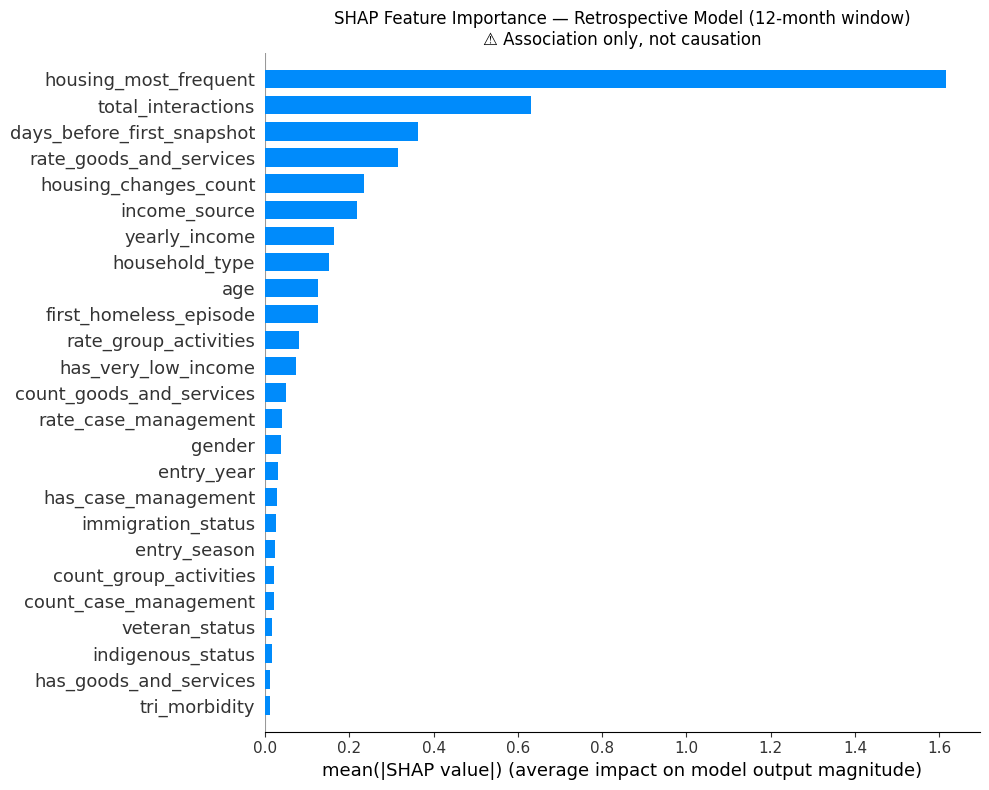

In [25]:
explainer_r = shap.TreeExplainer(model_r)
shap_vals = explainer_r.shap_values(X_r_test)
sv_r = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

shap.summary_plot(sv_r, X_r_test, plot_type='bar', max_display=25, show=False, plot_size=(10, 8))
plt.title('SHAP Feature Importance — Retrospective Model (12-month window)\n⚠️ Association only, not causation')
plt.tight_layout()
plt.show()

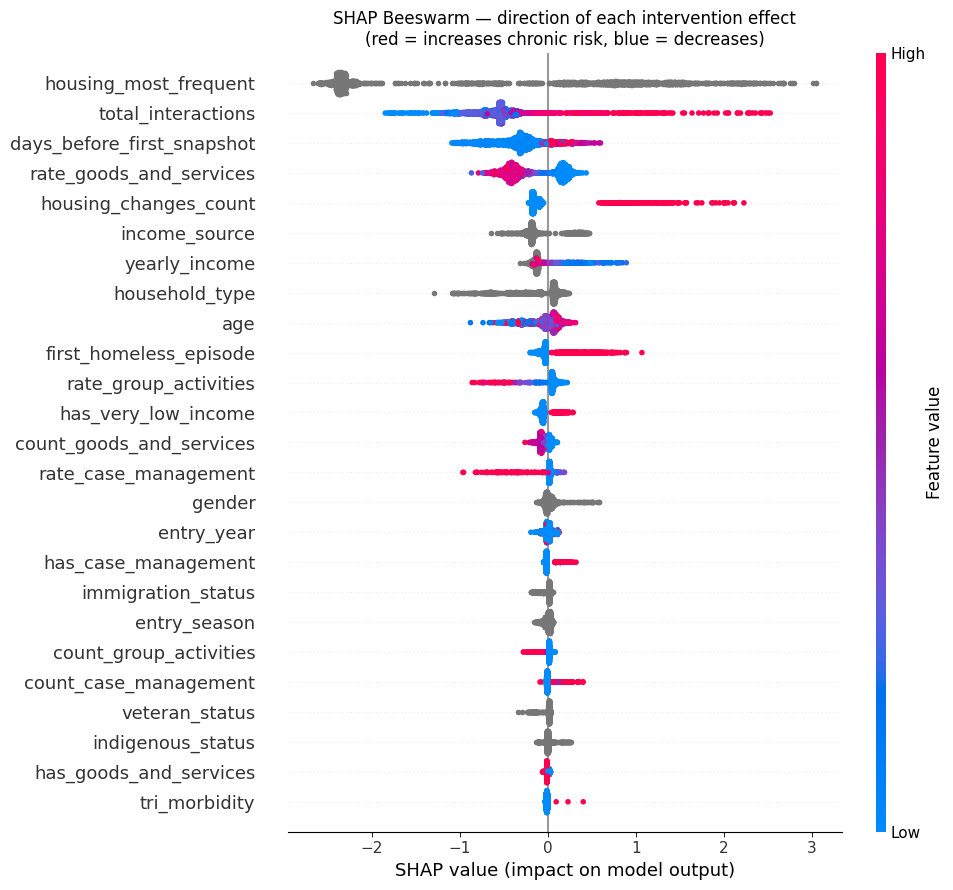

In [26]:
# Beeswarm: direction of effect
shap.summary_plot(sv_r, X_r_test, max_display=25, show=False, plot_size=(10, 9))
plt.title('SHAP Beeswarm — direction of each intervention effect\n(red = increases chronic risk, blue = decreases)')
plt.tight_layout()
plt.show()

## Component B-4: Descriptive analysis — chronic rate per intervention

In [27]:
has_cols = ['has_' + i.lower().replace(' ', '_').replace('/', '_') for i in INTERVENTIONS]
desc_df = X_r_test.copy()
desc_df['became_chronic'] = y_r_test.values

summary_rows = []
for intv, col in zip(INTERVENTIONS, has_cols):
    if col not in desc_df.columns:
        continue
    with_intv    = desc_df[desc_df[col] == 1]['became_chronic']
    without_intv = desc_df[desc_df[col] == 0]['became_chronic']
    summary_rows.append({
        'Intervention'    : intv,
        'n_with'          : len(with_intv),
        'chronic_rate_with'   : with_intv.mean(),
        'n_without'       : len(without_intv),
        'chronic_rate_without': without_intv.mean(),
        'diff'            : with_intv.mean() - without_intv.mean(),
    })

desc_summary = pd.DataFrame(summary_rows).sort_values('diff')
print("Chronic rate: with vs without each intervention (test set)")
print("Negative diff = intervention associated with LOWER chronic rate")
print()
print(desc_summary.round(3).to_string(index=False))
print("\n⚠️ These differences may reflect caseworker selection bias, not causal effects.")

Chronic rate: with vs without each intervention (test set)
Negative diff = intervention associated with LOWER chronic rate

        Intervention  n_with  chronic_rate_with  n_without  chronic_rate_without   diff
  Goods and Services    1482              0.101        867                 0.314 -0.213
   Housing Retention       6              0.167       2343                 0.179 -0.013
   Housing Placement      18              0.333       2331                 0.178  0.155
    Group Activities     113              0.345       2236                 0.171  0.174
     Case Management     201              0.468       2148                 0.152  0.315
               SPDAT      16              0.562       2333                 0.177  0.386
Service Restrictions      13              0.615       2336                 0.177  0.439
          Follow Ups       0                NaN       2349                 0.179    NaN

⚠️ These differences may reflect caseworker selection bias, not causal effects.


## Component B-5: Permutation Importance — signal validation

Permutation Importance (top 20 — validates real signal):
                   feature  importance_mean  importance_std
     housing_most_frequent           0.1660          0.0060
        total_interactions           0.0559          0.0030
            household_type           0.0130          0.0011
     housing_changes_count           0.0121          0.0008
    first_homeless_episode           0.0111          0.0009
days_before_first_snapshot           0.0108          0.0010
   rate_goods_and_services           0.0029          0.0021
      rate_case_management           0.0024          0.0006
                       age           0.0016          0.0007
     count_case_management           0.0016          0.0004
              entry_season           0.0008          0.0003
       has_case_management           0.0007          0.0003
         indigenous_status           0.0003          0.0003
        immigration_status           0.0003          0.0004
     rate_group_activities           0.0002

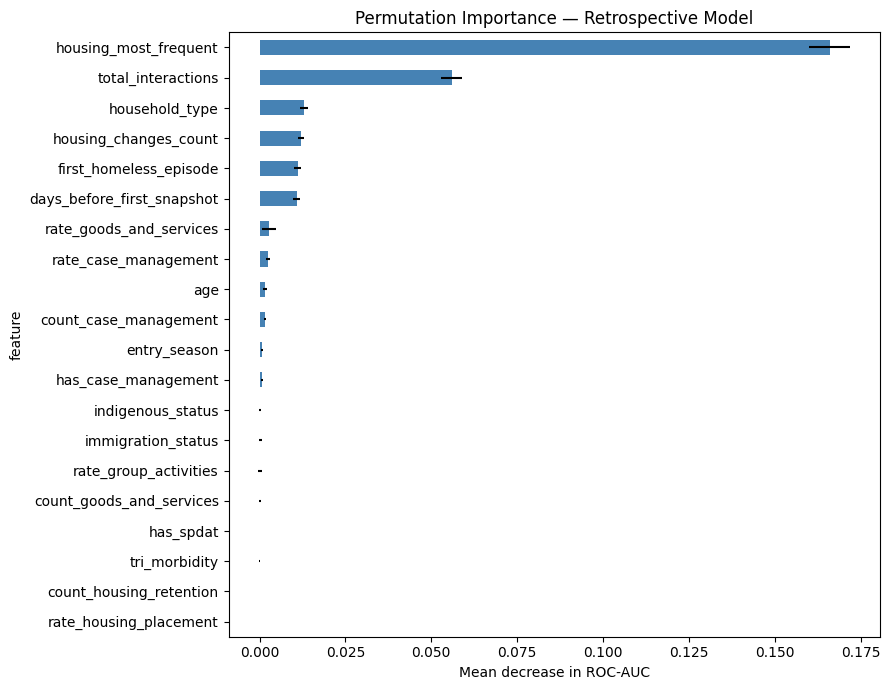

In [28]:
scorer = 'roc_auc'

perm = permutation_importance(
    model_r, X_r_test, y_r_test,
    n_repeats=10, random_state=42, scoring=scorer
)

perm_df = pd.DataFrame({
    'feature'           : X_r_test.columns,
    'importance_mean'   : perm.importances_mean,
    'importance_std'    : perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print("Permutation Importance (top 20 — validates real signal):")
print(perm_df.head(20).round(4).to_string(index=False))

perm_df.head(20).set_index('feature')['importance_mean'].sort_values().plot(
    kind='barh', figsize=(9, 7), color='steelblue',
    xerr=perm_df.head(20).set_index('feature')['importance_std'].reindex(
        perm_df.head(20).set_index('feature')['importance_mean'].sort_values().index
    )
)
plt.title('Permutation Importance — Retrospective Model')
plt.xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
plt.show()